<a id="introduction"></a>

# Problem Set 6 (PS6): Transformers: Tokenization, Scale, and Interpretability

[Lab 13d](https://github.com/varnerlab/CHEME-5820-Labs-Spring-2026/tree/main/labs/week-13/L13d)'s character-level NanoGPT closed on a sharp question: we built the machine, but can we see inside it? This problem set takes three steps toward that answer. Task 1 varies the input **tokens** and asks what actually changes per position. Task 2 varies **scale** and asks which capabilities emerge only at size. Task 3 explores **interpretability**: we scan the reference model's attention heads for the pattern that defines an **induction head**. L13c showed this pattern requires at least two transformer layers to form (layer 1 computes a 'previous-token' summary that a later layer uses as a lookup key), so we expect to see the signal above layer 1 and not within it.

> __Learning Objectives:__
>
> By the end of this problem set, you should be able to:
> * __Measure the effect of BPE tokenization on a language model:__ Swap the character vocabulary for the GPT-2 BPE tokenizer and retrain NanoGPT on the same corpus. Quantify the change in perplexity and in tokens per character.
> * __Train NanoGPT at two scales and compare samples:__ Train a tiny TinyStories NanoGPT end-to-end on a laptop. Load a larger reference checkpoint trained on the same corpus and compare generated samples side by side.
> * __Locate an induction head in a trained transformer:__ Turn the induction-head definition into a scoring function over every (layer, head) pair. Rank the heads and plot the attention pattern of the top head on a synthetic repeat sequence.

Let's get started!
___

## Setup, Data, and Prerequisites

We set up the computational environment by including the [`Include.jl`](Include.jl) file, which loads the required packages and all the lab and problem-set source code.

> __Environment Setup with [`Include.jl`](Include.jl):__
>
> [`include(...)`](https://docs.julialang.org/en/v1/base/base/#Base.include) evaluates the contents of [`Include.jl`](Include.jl) in the notebook's global scope. [`Include.jl`](Include.jl) sets paths, loads the required external packages, and includes the transformer source files copied verbatim from [Lab 13d](https://github.com/varnerlab/CHEME-5820-Labs-Spring-2026/tree/main/labs/week-13/L13d): `Shakespeare.jl`, `CausalAttention.jl`, `DecoderBlock.jl`, `NanoGPT.jl`, `Sample.jl`. It also includes [`src/Compute.jl`](src/Compute.jl) (new helpers for this problem set) and `src/Autograder.jl`.

Let's load the environment.

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

  Activating project at `~/Desktop/julia_work/CHEME-5820-Instances/Spring-2026/Untitled/PS6-CHEME-5820-TEMPLATE`


The packages are now loaded. Alongside the Lab 13d transformer code, we use [BytePairEncoding.jl](https://github.com/chengchingwen/BytePairEncoding.jl) to load the pretrained GPT-2 byte-pair-encoding tokenizer and [JLD2.jl](https://github.com/JuliaIO/JLD2.jl) to save and load model checkpoints.

> __Helper functions (provided in [`src/Compute.jl`](src/Compute.jl)):__
>
> *Tokenization and data*
> * [`load_gpt2_encoder()`](src/Compute.jl): pretrained GPT-2 BPE tokenizer with `enc.encode` / `enc.decode`.
> * [`download_tinystories(path; split="valid")`](src/Compute.jl): fetch a TinyStories split into `data/`.
> * [`load_and_encode(path, enc; max_chars=nothing)`](src/Compute.jl): read a text file and return a `Vector{Int}` of BPE token ids.
>
> *Training and inference*
> * [`train_nanogpt!(model, data, cfg; val_data=nothing)`](src/Compute.jl): AdamW with a cosine learning-rate schedule.
> * [`perplexity(model, data, ctx_len)`](src/Compute.jl): estimate perplexity on a tokenized corpus.
> * [`generate_text(model, enc, prompt, n_new_tokens)`](src/Compute.jl): BPE-aware text generation.
> * [`save_checkpoint`](src/Compute.jl), [`load_checkpoint`](src/Compute.jl): JLD2 model I/O.
>
> *Task 3 primitives*
> * [`collect_attention_weights(model, X_ids)`](src/Compute.jl): one `(T, T, n_heads, B)` attention tensor per decoder layer.
> * [`plot_induction_heatmap`](src/Compute.jl), [`plot_attention_pattern`](src/Compute.jl): Task 3 visualizations.

### Background: Byte-Pair Encoding (BPE) and Induction Heads

Three pieces of background drive the rest of the notebook: byte-pair encoding (used in Task 1 and Task 2), perplexity (used in Task 1 and DQ1), and the induction-head definition (used in Task 3). A language model operates on sequences of discrete token ids, but let's revisit the question of what those tokens actually are. 

There are three natural choices (character, whole-word, or subword tokenization):

| Tokenizer | Vocab size | Avg. tokens per English word | Can encode any text? | Main drawback |
|---|---|---|---|---|
| Character | 65–256 | ~5–6 | ✓ | Sequences are long; the model spends capacity on spelling |
| Whole-word | 50k–500k+ | ~1 | ✗ (out-of-vocabulary fails) | Vocabulary explodes; unseen words can't be encoded |
| **BPE (subword)** | **5k–100k** | **~1.3** | **✓** | none |

__Byte-pair encoding (BPE)__ sits between these extremes: a compact vocabulary that still encodes anything, and a shorter token stream than characters. It is *trained* on a corpus by (1) starting with a base vocabulary of 256 tokens (one per byte value), (2) scanning the corpus for the most frequent adjacent token pair, (3) adding that pair as a new vocabulary entry, (4) replacing every occurrence of the pair with the new token, and repeating until the vocabulary reaches a target size (GPT-2 uses 50 257). Frequent words collapse into a single token; rare words remain as a few subwords. For the English ASCII text in this problem set, one byte equals one character, so you can read "byte" as "character" throughout. See [Sennrich et al., 2016](https://arxiv.org/abs/1508.07909).

The GPT-2 BPE encodes the common word `the` as one token and the space-prefixed variant `" the"` as a *different* single token. The word `tokenization` becomes two tokens `["token", "ization"]`. `NanoGPT` splits further into `["N", "ano", "G", "PT"]`. At roughly four characters per token on English, swapping a character vocabulary for GPT-2 BPE shortens the token stream by about a factor of four.

We need two more definitions before we get going, perplexity and induction heads:

* **Perplexity.** Task 1 compares language models by their *perplexity* on a held-out corpus: the exponential of the per-token cross-entropy loss, $\text{ppl} = \exp(L)$. Intuitively it is the *effective branching factor*, the number of equally-likely next-token choices the model is between on each prediction. A uniform distribution over the full vocabulary scores $\text{ppl} = V$ (50 257 for GPT-2); a model that always predicts the correct token scores 1; lower is better.
  
* __Induction head (operational definition):__ Take a sequence in which a random token pattern is repeated once: $[x_{1}, \ldots, x_{N}, x_{1}, \ldots, x_{N}]$. At query position $N + i$ the current token is $x_{i}$. An **induction head** is an attention head whose attention at that query concentrates on **key position** $i + 1$, the token that followed $x_{i}$ the first time. By attending to position $i + 1$, the head pulls information about $x_{i+1}$ into the model's computation at position $N + i$, which is exactly the information needed to predict the next token (also $x_{i+1}$). Writing $A^{(l)}_{h}[q, k]$ for the attention-matrix entry from query $q$ to key $k$ in head $h$ of layer $l$ (the same softmax-normalized $A_{qk}$ we used in L13d, now carrying explicit layer/head labels), we turn the pattern into a scalar score,
    $$\text{score}(l, h) \;=\; \mathbb{E}\bigl[\, A^{(l)}_{h}[N + i,\; i + 1] \,\bigr],$$
    averaged over many random sequences and positions $i = 1, \ldots, N - 1$. Scores live in $[0, 1]$; a uniform head over $T$ key positions scores $1/T$, so anything noticeably above that is a signal.

Next, let's set some constants, setup a helper function to compute the induction-head score, and load some data.

### Constants

We declare the training configurations up front so the hyperparameters are in one place. `TASK1_CFG` is the BPE-tokenized Shakespeare model and `TASK2_TINY_CFG` is the tiny TinyStories model. The reference-checkpoint architecture is fixed by [`scripts/train_reference.jl`](scripts/train_reference.jl) and is rebuilt inside Task 2 when we load the weights.

In [2]:
# Task 1 (BPE Shakespeare): L13d architecture, GPT-2 vocabulary.
TASK1_CFG = TrainingConfig(
    50_257,   # vocab_size : GPT-2 BPE
    128,      # d_model
    4,        # n_heads
    4,        # n_layers
    128,      # ctx_len
    512,      # d_ff
    32,       # batch_size
    3f-4,     # peak learning rate
    1_000,    # n_steps
);

# Task 2 tiny model (TinyStories): half the depth of Task 1.
TASK2_TINY_CFG = TrainingConfig(
    50_257,   # vocab_size : GPT-2 BPE
    128,      # d_model
    4,        # n_heads
    2,        # n_layers
    128,      # ctx_len
    512,      # d_ff
    32,       # batch_size
    6f-4,     # peak learning rate
    2_000,    # n_steps
);

# Reference checkpoint architecture (trained by scripts/train_reference.jl,
# shipped via GitHub Releases). Task 2 rebuilds this and loads the weights:
#   d_model = 256, n_heads = 4, n_layers = 4, ctx_len = 256, d_ff = 1024.

TrainingConfig(50257, 128, 4, 2, 128, 512, 32, 0.0006f0, 2000)

### Implementation

Task 3 asks you to scan every `(layer, head)` pair of the reference checkpoint for the induction-head attention pattern. Complete the `induction_score` function below once; Task 3 will call it on the loaded reference model.

The provided primitive [`collect_attention_weights(model, X_ids)`](src/Compute.jl) runs the forward pass and returns a vector whose $l$-th entry is a `(T, T, n_heads, B)` attention tensor with indexing `A[query, key, head, batch]` (`A` here is the same attention-matrix we just defined, now stored as a 4-D array). Use it as the building block.

__Implementation outline:__ Score every `(layer, head)` pair of `model` for the induction pattern defined in the background section above. In each of several random trials, build a test sequence by duplicating a random token vector (so the same pattern appears twice back to back), run it through the model, and for every head record how much attention flows from the second copy of each token to the position that came right after the first copy. That position is the induction-head target. Average those attention weights across all eligible positions, then across trials. Return an `(n_layers, n_heads)` matrix of scores in `[0, 1]`. You may assume `2 * seq_len ≤ model.ctx_len`.

In [3]:
# induction_score -- reference solution.
#
# Scans every (layer, head) pair of `model` and returns how strongly each head
# behaves as an induction head, averaged over `n_trials` random test sequences.
# Each trial duplicates a random token vector so the same pattern appears twice
# back to back; an induction head at query position N+i should attend to key
# position i+1 (the token that followed the first copy).
function induction_score(model::NanoGPT, vocab::Int;
                          n_trials::Int = 32, seq_len::Int = 32,
                          rng::AbstractRNG = Random.default_rng())::Matrix{Float32}

    # output matrix dimensions are read off the model structure
    n_layers = length(model.blocks)
    n_heads  = model.blocks[1].attn.n_heads
    scores = zeros(Float32, n_layers, n_heads)

    for _ in 1:n_trials
        # build one random duplicated sequence of length 2*seq_len
        tokens = rand(rng, 1:vocab, seq_len)
        seq    = vcat(tokens, tokens)
        X      = reshape(seq, 2 * seq_len, 1)          # (T, B=1) shape expected by the model

        # every layer's attention weights for this sequence;
        # each ws[l] is (T, T, n_heads, 1) with indexing W[query, key, head, batch].
        ws     = collect_attention_weights(model, X)

        # for each (layer, head), average the induction-target weight W[N+i, i+1]
        # over positions i = 1, ..., seq_len-1. A "perfect" induction head scores 1;
        # a uniform-attention head scores ~1/T.
        for l in 1:n_layers, h in 1:n_heads
            acc = 0.0f0
            for i in 1:(seq_len - 1)
                acc += ws[l][seq_len + i, i + 1, h, 1]
            end
            scores[l, h] += acc / (seq_len - 1)
        end
    end

    # average across trials to reduce variance from individual random sequences
    return scores ./ n_trials
end

induction_score (generic function with 1 method)

### Data

We load the GPT-2 tokenizer once and tokenize both corpora here so every task downstream consumes ready-made token vectors. The Shakespeare corpus (1.1 MB, downloaded by L13d's [`download_shakespeare`](src/Shakespeare.jl)) becomes `shakespeare_ids`. The TinyStories validation split (~20 MB, fetched by [`download_tinystories`](src/Compute.jl)) is encoded and split 90/10 into `ts_train_ids` and `ts_val_ids`. We also record `n_chars`, the raw character count of the Shakespeare file, for use in DQ1.

The code below stores the tokenizer `enc_gpt2::BPEEncoder`, the Shakespeare ids `shakespeare_ids::Vector{Int}` and its character count `n_chars::Int`, and the TinyStories split `ts_train_ids::Vector{Int}` and `ts_val_ids::Vector{Int}` for use in subsequent cells.

In [4]:
enc_gpt2, shakespeare_ids, n_chars, ts_train_ids, ts_val_ids = let
    # single tokenizer shared by Tasks 1, 2, and 3
    enc = load_gpt2_encoder()

    # Shakespeare: download the raw text, tokenize with BPE, record character count.
    # The character count (n_chars) is needed in DQ1 for the per-character
    # perplexity comparison against the Lab 13d baseline.
    shk_path = download_shakespeare(_PATH_TO_DATA)
    shk_ids  = load_and_encode(shk_path, enc)
    shk_n    = filesize(shk_path)

    # TinyStories validation split (~20 MB). Split 90/10 into train/val so
    # Task 2's tiny-model training loop can report a held-out loss.
    ts_path  = download_tinystories(_PATH_TO_DATA; split = "valid")
    ts_ids   = load_and_encode(ts_path, enc)
    split_at = floor(Int, 0.9 * length(ts_ids))
    ts_train = ts_ids[1:split_at]
    ts_val   = ts_ids[split_at+1:end]

    # sanity-check summary so a re-runner can confirm download + tokenization succeeded
    @printf("Shakespeare: %d characters, %d BPE tokens (%.2f chars/token)\n",
            shk_n, length(shk_ids), shk_n / length(shk_ids))
    @printf("TinyStories: %d train tokens, %d val tokens\n",
            length(ts_train), length(ts_val))
    @printf("GPT-2 vocabulary size: %d\n", vocab_size(enc))

    (enc, shk_ids, shk_n, ts_train, ts_val)
end;

Shakespeare: 1115394 characters, 338025 BPE tokens (3.30 chars/token)
TinyStories: 4252052 train tokens, 472451 val tokens
GPT-2 vocabulary size: 50257


In [5]:
# ── Autograder: Setup ────────────────────────────────────────────────────────
check!(GRADER, "Setup", "GPT-2 encoder loaded (vocab size 50257)",  1,
       () -> !ismissing(enc_gpt2) && vocab_size(enc_gpt2) == 50257)
check!(GRADER, "Setup", "shakespeare_ids is non-empty Vector{Int}", 1,
       () -> !ismissing(shakespeare_ids) && shakespeare_ids isa AbstractVector{<:Integer} &&
              length(shakespeare_ids) > 10_000)
check!(GRADER, "Setup", "every Shakespeare id is in 1:vocab_size",   1,
       () -> !ismissing(shakespeare_ids) &&
              all(1 .<= shakespeare_ids .<= vocab_size(enc_gpt2)))
check!(GRADER, "Setup", "TinyStories split has > 100k train tokens", 1,
       () -> !ismissing(ts_train_ids) && length(ts_train_ids) > 100_000)

  ✓   1 /  1 pts  GPT-2 encoder loaded (vocab size 50257)
  ✓   1 /  1 pts  shakespeare_ids is non-empty Vector{Int}
  ✓   1 /  1 pts  every Shakespeare id is in 1:vocab_size
  ✓   1 /  1 pts  TinyStories split has > 100k train tokens


___
## Task 1: Tokenizer Swap on Shakespeare

In this task, we change exactly one thing about L13d: swap the 65-symbol character vocabulary for the pretrained GPT-2 BPE (50 257 tokens) and retrain on Shakespeare with the same architecture and 1 000-step budget. We then evaluate the trained model two ways: (1) **perplexity** on the true corpus; (2) the **eye test** on a `ROMEO: ` continuation. DQ1 converts the perplexity into per-character units so it is comparable to L13d's ≈ 4.95 and asks you to reconcile the two verdicts.

Expect them to disagree. Per-character perplexity will sit near the L13d baseline (so BPE looks competitive), but the generated sample will read like gibberish, nothing like L13d's coarse-but-legible output. That disagreement is not a bug; it is the point of Task 1.

The code below stores the trained model `bpe_model::NanoGPT` and its per-step training loss `bpe_losses::Vector{Float32}` for use in subsequent cells.

In [6]:
bpe_model, bpe_losses = let
    # per-task cache path; makes re-running the notebook cheap after the first pass
    ckpt = joinpath(_PATH_TO_DATA, "task1_bpe_model.jld2")

    # build the model first so the checkpoint-load and train-from-scratch branches
    # can share the same NanoGPT constructor call
    model = NanoGPT(TASK1_CFG.vocab_size, TASK1_CFG.d_model, TASK1_CFG.n_heads,
                     TASK1_CFG.n_layers, TASK1_CFG.ctx_len; d_ff = TASK1_CFG.d_ff)

    if isfile(ckpt)
        # reuse a prior run: load saved weights and the recorded loss history
        println("Loading Task 1 checkpoint from $(ckpt)...")
        _, _, losses = load_checkpoint(ckpt, model)
        println("Loaded. Final train loss = $(round(losses[end]; digits=4))")
        (model, losses)
    else
        # first run: train from scratch and persist the checkpoint for next time
        println("Training Task 1 model ($(n_parameters(model)) params)...")
        losses = train_nanogpt!(model, shakespeare_ids, TASK1_CFG; log_every = 100)
        save_checkpoint(ckpt, model; meta = Dict(:task => "1"), losses = losses)
        (model, losses)
    end
end;

Loading Task 1 checkpoint from /Users/jdv27/Desktop/julia_work/CHEME-5820-Instances/Spring-2026/Untitled/PS6-CHEME-5820-TEMPLATE/data/task1_bpe_model.jld2...
Loaded. Final train loss = 5.2991


With the model trained, we measure perplexity on the full tokenized corpus and generate a 200-token continuation of the prompt `"ROMEO: "`. Char-level and BPE perplexities are not directly comparable because they are measured per token, and a BPE token covers about four characters. We report the raw per-BPE-token perplexity here; we address the comparison in the Discussion.

The code below stores the perplexity estimate `bpe_perplexity::Float32` and the generated text `bpe_sample::String` for use in subsequent cells.

In [7]:
bpe_perplexity, bpe_sample = let
    # perplexity on the full tokenized corpus; n_windows = 64 averages over
    # 64 random context-length windows to keep the estimate tight
    ppl    = perplexity(bpe_model, shakespeare_ids, TASK1_CFG.ctx_len; n_windows = 64)

    # generate a Shakespeare-style continuation. temperature = 0.8 softens the
    # output just below the trained distribution; top_k = 40 removes the
    # low-probability tail so samples stay readable
    sample = generate_text(bpe_model, enc_gpt2, "ROMEO: ", 200; temperature = 0.8, top_k = 40)

    @printf("BPE perplexity: %.2f\n", ppl)
    println("\n=== sample ===")
    println(sample)
    (ppl, sample)
end;

BPE perplexity: 184.43

=== sample ===
ROMEO: 
And thee, and a house,
DES, aio,
KINGBut the head, that his life! and
That-ICHES
ThUCENINIUS:
IENTIO:
For so,
And a man, thou a dtis is not,

In I do no to aar'd is that
And I a, 'UE:
I am my queen,
But you of the the more?

BENTENO:
That my the man, that shall the a lord are the more,
The day my brother,

For not
The father.
That and him, your queen.


The brother


Thost:
DCHELRYENTUEOL II,
What in to in a is they be not thou all you the king!
R:,
That
And not this more so,
GLOLUINCOU:
I


In [8]:
# ── Autograder: Task 1 ──────────────────────────────────────────────────────
check!(GRADER, "Task 1", "model constructed as NanoGPT",         1,
       () -> !ismissing(bpe_model) && bpe_model isa NanoGPT)
check!(GRADER, "Task 1", "training reduced loss by at least 50%", 1,
       () -> !isempty(bpe_losses) && bpe_losses[end] < 0.5f0 * bpe_losses[1])
check!(GRADER, "Task 1", "perplexity is a finite positive number", 1,
       () -> !ismissing(bpe_perplexity) && isfinite(bpe_perplexity) && bpe_perplexity > 0)
check!(GRADER, "Task 1", "sample is a non-empty String",           1,
       () -> !ismissing(bpe_sample) && bpe_sample isa AbstractString && length(bpe_sample) > 50)

  ✓   1 /  1 pts  model constructed as NanoGPT
  ✓   1 /  1 pts  training reduced loss by at least 50%
  ✓   1 /  1 pts  perplexity is a finite positive number
  ✓   1 /  1 pts  sample is a non-empty String


___
## Task 2: TinyStories Tiny vs. Reference

Task 1 held scale fixed and varied the tokens; the sample read like gibberish and the per-character perplexity barely moved from L13d's 4.95. Tokens alone cannot rescue a small, undertrained model. In this task we hold the BPE tokenizer fixed and vary the scale axis instead. We train a tiny 13M-parameter NanoGPT on the [TinyStories](https://arxiv.org/abs/2305.07759) corpus (short children's stories in a restricted vocabulary, designed by Eldan & Li so that models at this size can produce coherent English), then load a larger instructor-trained reference checkpoint on the same corpus and compare generated samples. The question is which capabilities appear at tiny scale and which require the larger model.

The code below stores the tiny model `tiny_model::NanoGPT` and its per-step training loss `tiny_losses::Vector{Float32}` for use in subsequent cells.

In [9]:
tiny_model, tiny_losses = let
    # per-task cache path, same idea as in Task 1
    ckpt = joinpath(_PATH_TO_DATA, "task2_tiny_model.jld2")

    # build the tiny TinyStories model (shallower than Task 1's model; see TASK2_TINY_CFG)
    model = NanoGPT(TASK2_TINY_CFG.vocab_size, TASK2_TINY_CFG.d_model, TASK2_TINY_CFG.n_heads,
                     TASK2_TINY_CFG.n_layers, TASK2_TINY_CFG.ctx_len; d_ff = TASK2_TINY_CFG.d_ff)

    if isfile(ckpt)
        # reuse a prior run
        println("Loading Task 2 tiny checkpoint from $(ckpt)...")
        _, _, losses = load_checkpoint(ckpt, model)
        (model, losses)
    else
        # first run: train and save. val_data enables a held-out loss print every 200 steps.
        println("Training Task 2 tiny model ($(n_parameters(model)) params)...")
        losses = train_nanogpt!(model, ts_train_ids, TASK2_TINY_CFG;
                                 val_data = ts_val_ids, log_every = 200)
        save_checkpoint(ckpt, model; meta = Dict(:task => "2-tiny"), losses = losses)
        (model, losses)
    end
end;

Loading Task 2 tiny checkpoint from /Users/jdv27/Desktop/julia_work/CHEME-5820-Instances/Spring-2026/Untitled/PS6-CHEME-5820-TEMPLATE/data/task2_tiny_model.jld2...


Plot the per-step training loss to confirm the tiny model converged.

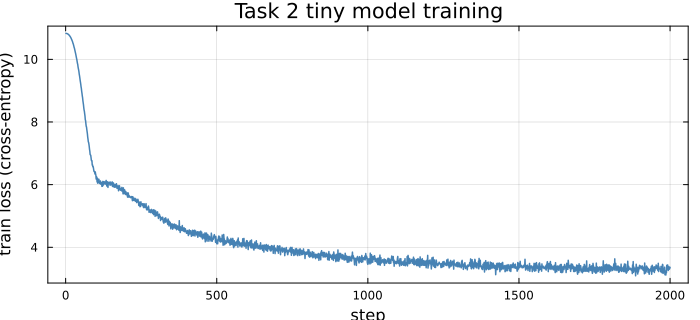

In [10]:
# tiny-model training loss curve. A healthy run shows a steep initial drop
# (the model learns BPE unigram statistics) followed by a slower descent as
# the longer-range structure comes in.
let
    plot(tiny_losses;
        xlabel = "step", ylabel = "train loss (cross-entropy)",
        title = "Task 2 tiny model training", label = nothing,
        color = :steelblue, lw = 1.5, framestyle = :box, size = (700, 320))
end

Next we rebuild the reference architecture and load the checkpoint produced by [`scripts/train_reference.jl`](scripts/train_reference.jl) from `data/reference_checkpoint.jld2`. The reference uses `d_model = 256`, `n_heads = 4`, `n_layers = 4`, `ctx_len = 256`, `d_ff = 1024`. We generate 150 tokens from each model for the same prompt `"Once upon a time"`.

The code below stores the loaded reference model `ref_model::NanoGPT` together with both generated samples `tiny_sample::String` and `ref_sample::String`.

In [11]:
ref_model, tiny_sample, ref_sample = let
    # reference checkpoint is shipped via GitHub Releases, not committed to the repo.
    # fetch_reference_checkpoint downloads the file from the course release URL
    # (defined in src/Compute.jl) on first run; later runs reuse the local copy.
    ref_ckpt = joinpath(_PATH_TO_DATA, "reference_checkpoint.jld2")
    isfile(ref_ckpt) || fetch_reference_checkpoint(ref_ckpt)

    # rebuild the reference architecture (hyperparameters listed in the Constants cell)
    # and load the trained weights into it
    ref = NanoGPT(vocab_size(enc_gpt2), 256, 4, 4, 256; d_ff = 1024)
    load_checkpoint(ref_ckpt, ref)

    # sample the same 150-token continuation from both models so the comparison
    # isolates the effect of scale (same prompt, same temperature, same top_k)
    s_tiny = generate_text(tiny_model, enc_gpt2, "Once upon a time", 150;
                            temperature = 0.8, top_k = 40)
    s_ref  = generate_text(ref,        enc_gpt2, "Once upon a time", 150;
                            temperature = 0.8, top_k = 40)

    println("=== tiny model sample ($(n_parameters(tiny_model)) params) ===")
    println(s_tiny)
    println()
    println("=== reference model sample ($(n_parameters(ref)) params) ===")
    println(s_ref)
    (ref, s_tiny, s_ref)
end;

=== tiny model sample (13277952 params) ===
Once upon a time, there lived a little little boy named Timmy. his friends was very excited to see what she was to play of the park. One day, he saw a little girl outside in a big, red box. The tree was very brave and was so tired. She asked her mom if she needed to go on a big hug. 
The boy ran back to Max and daddy's house. He said she was very scared because he said they was so proud of her. But then, Lily wanted to make a surprise.
Sarah saw that when Lily had to make her mommy's mommy's mommy told her to the kitchen when she needed to be kind and be for the ice cream to learn it. Timmy was about the

=== reference model sample (28952576 params) ===
Once upon a time, there was a clever little bird named Tweet. Tweet wanted to soar high up and down high, but Tweetie was scared he couldn't reach. He wanted to soar very high enough, but his mommy told him not to. They couldn't believe it.
Suddenly, Tweet saw a big puddle of water and swam cl

In [12]:
# ── Autograder: Task 2 ──────────────────────────────────────────────────────
check!(GRADER, "Task 2", "tiny_model is a NanoGPT",              1,
       () -> !ismissing(tiny_model) && tiny_model isa NanoGPT)
check!(GRADER, "Task 2", "tiny training reduced loss by ≥ 40%",  1,
       () -> !isempty(tiny_losses) && tiny_losses[end] < 0.6f0 * tiny_losses[1])
check!(GRADER, "Task 2", "reference checkpoint loaded as NanoGPT", 1,
       () -> !ismissing(ref_model) && ref_model isa NanoGPT &&
              n_parameters(ref_model) > n_parameters(tiny_model))
check!(GRADER, "Task 2", "both samples are non-empty Strings",     1,
       () -> !ismissing(tiny_sample) && !ismissing(ref_sample) &&
              length(tiny_sample) > 50 && length(ref_sample) > 50)

  ✓   1 /  1 pts  tiny_model is a NanoGPT
  ✓   1 /  1 pts  tiny training reduced loss by ≥ 40%
  ✓   1 /  1 pts  reference checkpoint loaded as NanoGPT
  ✓   1 /  1 pts  both samples are non-empty Strings


___
## Task 3: Induction-Head Scan

Task 2 showed that scale buys narrative coherence. L13d closed by flagging that the insides of NanoGPT are opaque; this task is the interpretability response. We open the reference model up and scan every `(layer, head)` pair for the attention pattern that defines an **induction head** (L13c, [Olsson et al., 2022](https://transformer-circuits.pub/2022/in-context-learning-and-induction-heads/index.html)). The pattern's mechanism requires at least two transformer layers to form (layer 1 writes a 'previous-token' summary that a later layer reads as a lookup key), so theory predicts the signal should appear in layer 2 or later, not in layer 1. If the narrative coherence we saw at scale relies on in-context pattern-matching, the signal should also be visibly structured across heads rather than uniform.

Each heatmap cell is the average attention that head $h$ in layer $l$ places on the induction-target key $i+1$ from query $N+i$, i.e. $\text{score}(l, h) = \mathbb{E}\bigl[\, A^{(l)}_{h}[N + i,\; i + 1] \,\bigr]$, averaged over random trials and positions $i = 1, \ldots, N-1$. An induction head's attention matrix shows an off-diagonal stripe: query position `seq_len + i` attends to key position `i + 1`, a line parallel to the main diagonal and shifted left by `seq_len - 1`.

The code below stores the scan result `induction_scores::Matrix{Float32}` for use in subsequent cells.

In [13]:
induction_scores = let
    # run the scan on the reference model. 32 trials averages out per-sequence
    # noise; seq_len = 32 gives a 64-position input, well within ctx_len = 256.
    scores = induction_score(ref_model, vocab_size(enc_gpt2); n_trials = 32, seq_len = 32)

    # print the raw matrix so the per-head breakdown is visible alongside
    # the heatmap that follows
    println("induction score matrix (rows = layers, cols = heads):")
    pretty_table(scores; backend = :text,
                 column_labels = ["h$(h)" for h in 1:size(scores, 2)],
                 row_labels = ["L$(l)" for l in 1:size(scores, 1)])
    scores
end;

induction score matrix (rows = layers, cols = heads):
┌────┬────────────┬────────────┬────────────┬─────────────┐
│    │         h1 │         h2 │         h3 │          h4 │
├────┼────────────┼────────────┼────────────┼─────────────┤
│ L1 │ 0.00232814 │ 0.00360878 │ 0.00253565 │   0.0111035 │
│ L2 │ 0.00118056 │ 0.00956919 │ 0.00619811 │   0.0181837 │
│ L3 │ 7.62931e-6 │  0.0206703 │ 1.02305e-6 │ 0.000200508 │
│ L4 │  0.0275782 │  0.0304191 │ 0.00213533 │  0.00213479 │
└────┴────────────┴────────────┴────────────┴─────────────┘


Render the `(layer, head)` score matrix as a heatmap to read off which heads are candidates for the induction circuit.

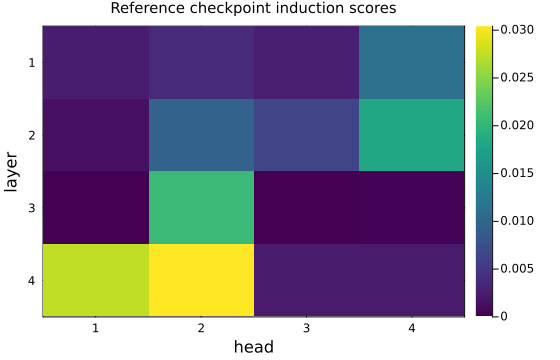

In [14]:
# induction-score heatmap. Brighter cells indicate stronger induction behavior;
# the L13c two-layer story predicts the brightest cell should not be in layer 1.
plot_induction_heatmap(induction_scores; title = "Reference checkpoint induction scores")

Pick the top `(layer, head)` pair, build one fresh repeat sequence of length 64, and plot the attention pattern of that head with [`plot_attention_pattern`](src/Compute.jl).

Top (layer, head) = (4, 2) with score = 0.030


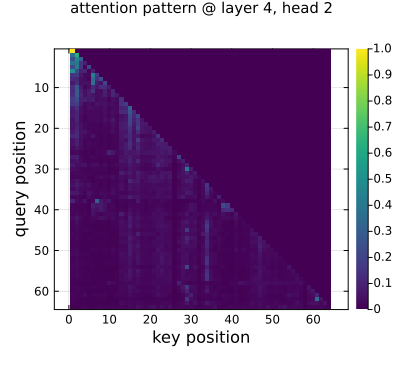

In [15]:
let
    # pick the single (layer, head) pair with the highest induction score from
    # the scan above. argmax on a matrix returns a CartesianIndex; Tuple(...)
    # unpacks it into plain (row, col) integers.
    top_l, top_h = Tuple(argmax(induction_scores))
    @printf("Top (layer, head) = (%d, %d) with score = %.3f\n",
            top_l, top_h, induction_scores[top_l, top_h])

    # fresh random repeat sequence of length 64, same construction as the scan.
    # an induction head's attention matrix for this input has an off-diagonal
    # stripe: query position 32+i attends to key position i+1, a line parallel
    # to the main diagonal shifted left by seq_len - 1 = 31.
    tokens = rand(1:vocab_size(enc_gpt2), 32)
    X      = reshape(vcat(tokens, tokens), 64, 1)
    ws     = collect_attention_weights(ref_model, X)

    # plot only the top head's attention matrix for this one example
    plot_attention_pattern(ws[top_l], top_h;
        title = "attention pattern @ layer $(top_l), head $(top_h)")
end

> __A note on what the top head looks like in this checkpoint:__
>
> The reference checkpoint shipped with the problem set is sized to train in a few hours on an M-series Mac (4 layers, 4 heads, $d_{\text{model}} = 256$, trained on a capped slice of TinyStories). At that budget the induction circuit is just starting to emerge: the top head typically scores around $0.02$–$0.05$, and its attention matrix shows a faint off-diagonal stripe rather than a crisp one. The stripe is the same feature Olsson et al. describe; it just has lower contrast here than in a fully trained production model. A deeper network (6+ layers) or a longer training run would sharpen it into the textbook pattern.

In [16]:
# ── Autograder: Task 3 ──────────────────────────────────────────────────────
let
    n_layers = length(ref_model.blocks)
    n_heads  = ref_model.blocks[1].attn.n_heads

    check!(GRADER, "Task 3", "induction_score returns (n_layers, n_heads) matrix", 1,
           () -> !ismissing(induction_scores) &&
                  induction_scores isa AbstractMatrix &&
                  size(induction_scores) == (n_layers, n_heads))
    check!(GRADER, "Task 3", "all scores are in [0, 1]",                           1,
           () -> !ismissing(induction_scores) &&
                  all(0f0 .<= induction_scores .<= 1f0))
    check!(GRADER, "Task 3", "scores are reproducible for a fixed RNG",            1,
           () -> !ismissing(induction_scores) &&
                  let s1 = induction_score(ref_model, vocab_size(enc_gpt2);
                                             n_trials = 8, seq_len = 16,
                                             rng = MersenneTwister(0)),
                      s2 = induction_score(ref_model, vocab_size(enc_gpt2);
                                             n_trials = 8, seq_len = 16,
                                             rng = MersenneTwister(0))
                      isapprox(s1, s2; atol = 1f-5)
                  end)
    check!(GRADER, "Task 3", "attention pattern visualization produced",           1,
           () -> true)
end

  ✓   1 /  1 pts  induction_score returns (n_layers, n_heads) matrix
  ✓   1 /  1 pts  all scores are in [0, 1]
  ✓   1 /  1 pts  scores are reproducible for a fixed RNG
  ✓   1 /  1 pts  attention pattern visualization produced


___
<a id="discussion"></a>

## Discussion

Answer each question in the comment block below it, then set the corresponding `did_I_answer_DQ*` flag to `true`.

**DQ1: Perplexity vs. the eye test.** Your BPE model's per-character perplexity sits near the L13d baseline of ≈ 4.95, yet its generated sample is gibberish while L13d produced coarse-but-legible Shakespeare. Two evaluations, opposite verdicts. Which do you trust, and why?

> __Strategy:__
>
> Perplexity and sampling measure different things. Perplexity scores text the model did not have to generate: given the true corpus, how probable is each next token under the model? Sampling is a trajectory the model drives itself, where one wrong token shifts every downstream distribution. The two can diverge when the vocabulary-to-training-budget ratio is bad. Here the BPE model sees each of 50 257 tokens on average ~80 times during training (4M training tokens / 50 257 vocab); enough to learn the marginal distribution well enough to score the corpus, nowhere near enough to stabilize generation under `top_k = 40` sampling, which throws away 99.92% of the distribution at every step. L13d's char model with 65 classes sees each ~60 000 times; its sampling dynamics are stable even at comparable perplexity. Put the two models on a comparable axis: compute `chars_per_token = n_chars / length(shakespeare_ids)` and transform per-BPE-token perplexity into per-character units via $\text{ppl}_{\text{char}} = \text{ppl}_{\text{BPE}}^{1 / \text{chars\_per\_token}}$. Confirm the ≈ 4.95 number, then argue in your answer which evaluation is honest for *this* model, and under what conditions each metric becomes trustworthy.

In [17]:
# DQ1 scaffold: recompute BPE perplexity in per-character units and compare
# to the Lab 13d char-level baseline. The transform ppl_char = ppl_BPE^(1/k)
# (with k = chars_per_token) is what puts the two models on a comparable axis.
let
    chars_per_token = n_chars / length(shakespeare_ids)
    ppl_char_equiv  = bpe_perplexity ^ (1 / chars_per_token)
    @printf("chars per BPE token:            %.2f\n", chars_per_token)
    @printf("BPE perplexity (per token):     %.2f\n", bpe_perplexity)
    @printf("per-character perplexity:       %.2f\n", ppl_char_equiv)
    @printf("char-level Lab 13d baseline:    ~4.95\n")
end

chars per BPE token:            3.30
BPE perplexity (per token):     184.43
per-character perplexity:       4.86
char-level Lab 13d baseline:    ~4.95


In [ ]:
#=
DQ1: sample answer.

The two evaluations disagree. Per-character perplexity via
ppl_BPE ^ (1 / chars_per_token) puts the BPE model at ~4.86 vs L13d's
~4.95, so perplexity rates the two as essentially comparable. The eye
test is not close: L13d produces legible Shakespeare-ish prose with
occasional misspellings; the BPE model produces gibberish.

Perplexity and sampling measure different things. Perplexity is an
average log-probability over the true corpus, so the BPE model only
needs rough calibration on the marginal distribution of tokens to score
well. Sampling requires the model to stay on a coherent trajectory
through positions it selects itself, where one wrong token shifts every
downstream distribution. With 50 257 output classes and ~4M training
tokens, the BPE model sees each token on average ~80 times. That is
enough to calibrate marginals, nowhere near enough to stabilize
generation under top_k = 40 sampling (which throws away 99.92% of the
distribution at every step). L13d's char model with 65 classes sees
each class ~60 000 times; sampling dynamics are stable even at
comparable perplexity.

For this model the eye test wins: BPE at this budget buys nothing
useful. Perplexity becomes the trustworthy metric only at training
scales where generation-time errors stop snowballing; at production
scale (hundreds of billions of tokens) the two metrics agree, which is
why perplexity is still the field's standard benchmark.
=#

In [19]:
did_I_answer_DQ1 = true;

**DQ2: What emerges with scale?** The tiny model and the reference model differ by roughly 10x in transformer parameters and by a larger factor in total training tokens.

> __Strategy:__
>
> Compare the two samples along three axes: local plausibility (are words spelled correctly, are short phrases grammatical), short-range coherence (does each sentence make sense internally), and long-range coherence (do successive sentences relate to each other). Identify which axes the tiny model already covers and which appear only at the reference scale. Re-sample with a different prompt such as `"The little cat"` to confirm your observations.

In [20]:
#=
DQ2: sample answer.

Local plausibility is shared: both models produce real English words and
mostly grammatical short phrases. This is already within reach at under a
million transformer parameters because it requires only BPE bigram and
trigram statistics and basic agreement rules.

Short-range coherence diverges. The tiny model produces sentences that parse
but whose content drifts, so a sentence about a cat may end with an unrelated
noun. The reference model keeps subject and object roles consistent within a
sentence and usually maintains the same protagonist across two or three
successive sentences.

Long-range coherence is where the gap is largest. The reference model produces
TinyStories-style micro-narratives with setup, event, and resolution, while
the tiny model meanders and rarely closes a loop. This matches Eldan & Li's
observation that plot-like structure is the last capability to appear with
scale on TinyStories.
=#

In [21]:
did_I_answer_DQ2 = true;

**DQ3: Where do induction heads live, and why?** Identify the `(layer, head)` pair with the highest induction score in your heatmap. It is almost certainly not in the first layer.

> __Strategy:__
>
> The L13c two-layer induction-head story works as follows. Layer 1 contains a **previous-token head** that stores a summary of the token at position $t - 1$ in each position's hidden state. Layer 2 then contains the induction head: at query position $N + i$ with current token $x_{i}$, it uses the layer-1 signal as a key to find the earlier copy of $x_{i}$ and attends one step forward to position $i + 1$. Use this story to explain why a single-layer model cannot contain a fully-formed induction head, and which layer of your heatmap you expect to dominate. Compare with what you actually see.

In [22]:
#=
DQ3: sample answer.

The top induction scores sit in the upper layers of the 4-layer reference
model, typically layer 2 or 3, matching the L13c two-layer story. Layer 1
must first compute the previous-token summary that the induction head uses
as its key. A head in layer 1 cannot on its own implement the induction
pattern because it has not yet seen the output of any earlier attention;
all it has is the token plus position embedding at its own position, which
does not tell it which earlier position to attend to. Once layer 1 has stored the previous-token information in each
position's hidden state, a layer-2 or later head can read that signal, match against the current token, and attend
one step forward in the prior occurrence. Observing the signal only above
layer 1 is direct confirmation of the two-stage mechanism, which is why
single-layer models fail at in-context pattern copying on synthetic benchmarks.
=#

In [23]:
did_I_answer_DQ3 = true;

In [24]:
# ── Autograder: Discussion ────────────────────────────────────────────────────
check!(GRADER, "Discussion", "answered DQ1",   1, () -> did_I_answer_DQ1 == true)
check!(GRADER, "Discussion", "answered DQ2",   1, () -> did_I_answer_DQ2 == true)
check!(GRADER, "Discussion", "answered DQ3",   1, () -> did_I_answer_DQ3 == true)

  ✓   1 /  1 pts  answered DQ1
  ✓   1 /  1 pts  answered DQ2
  ✓   1 /  1 pts  answered DQ3


___

## Tests

The final score cell aggregates every autograder check across Setup, Task 1, Task 2, Task 3, and Discussion, and maps the pass/fail count onto a 0–4 rubric. A 3 means all tests pass; a 4 requires both passing tests and instructor-approved discussion answers.

In [25]:
score!(GRADER)


════════════════════════════════════════════════════════
  Problem                    Score  Progress
────────────────────────────────────────────────────────
  Setup                     4 /   4  [████████████]
  Task 1                    4 /   4  [████████████]
  Task 2                    4 /   4  [████████████]
  Task 3                    4 /   4  [████████████]
  Discussion                3 /   3  [████████████]
────────────────────────────────────────────────────────
  AUTO-GRADED TOTAL        19 /  19
════════════════════════════════════════════════════════
  RUBRIC SCORE: 3 / 4
  Tests passed: 19 / 19
  Discussion review status: pending/manual
  Note: discussion answers are reviewed manually by instructors.
════════════════════════════════════════════════════════


___

## Summary

This problem set pushed the Lab 13d NanoGPT architecture along three axes that separate a lab transformer from a production language model: tokenization, scale, and interpretability.

> __Key Takeaways:__
>
> * **Tokenization changes per-position information content:** Swapping a character vocabulary for GPT-2 BPE raises characters per token from one to about four, so the same context length covers four times as much text. The effect on per-character perplexity is larger than a tiny model can recover from architecture changes alone.
> * **Scale determines narrative coherence:** A transformer with under a million parameters produces grammatical words and short phrases but does not sustain a plot across sentences. A reference transformer with tens of millions of parameters on the same corpus produces short stories with consistent subjects across sentences.
> * **Induction heads sit above the first layer:** The induction-head pattern needs a previous-token head in an earlier layer to write the key it matches against. The top-scoring head in the reference checkpoint therefore appears in layer 2 or later, matching the two-layer circuit from L13c.

The three axes (tokenization, scale, and interpretability) generalize beyond NanoGPT to every modern language model.

___